# Logistic Regression and Classification

We are not always interested in representing variables as continuous, where they can represent an infinite number of real decimal values. There are situations where we would rather variables be discrete, or representative of whole numbers, integers, or booleans (1/0, true/false). 

Logistic regression is a type of regression that predicts a probability of an outcome given one or more independent variables. This in turn can be used for classification, which is predicting categories rather than real numbers as we did with linear regression. Logistic regression is trained on an output variable that is discrete (a binary 1 or 0) or a categorical number (which is a whole number). It does output a continuous variable in the form of probability, but that can be converted into a discrete value with a threshold.

## The Logistic Function

The logistic function is an S-shaped curve (also known as a sigmoid curve) that, for a given set of input variables, produces an output variable between 0 and 1. Because the output variable is between 0 and 1 it can be used to represent a probability.

Here is the logistic function that outputs a probability `y` for one input variable `x`:

$$ y = \frac{1.0}{1.0 + e^{-(\beta_0 + \beta_1 x)}} $$

This formula uses Euler’s number `e`. The `x` variable is the independent/input variable. `$\beta_0$` and `$\beta_1$` are the coefficients we need to solve for.

In [1]:
import math

def predict_probability(x, b0, b1):
    p = 1.0 / (1.0 + math.exp(-(b0 + b1 * x)))
    return p

Let’s plot to see what it looks like, and assume $\beta_0$ = -2.823 and $\beta_1$ = 0.62. We will use SymPy.

1.0/(1.0 + 16.8272567955368*exp(-0.62*x))


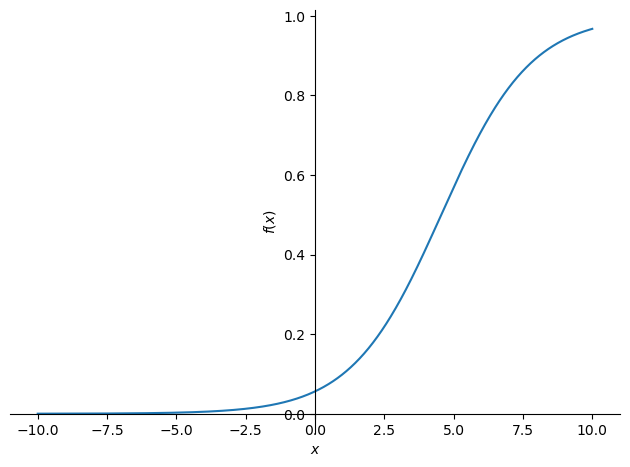

In [2]:
from sympy import *
b0, b1, x = symbols('b0 b1 x')

p = 1.0 / (1.0 + exp(-(b0 + b1 * x)))

p = p.subs(b0,-2.823)
p = p.subs(b1, 0.620)
print(p)

plot(p)

## Fitting the Logistic Curve

How do you fit the logistic curve to a given training dataset? We need to solve for the $\beta_0$ and $\beta_1$ coefficients to fit our logistic function. 

Unlike linear regression where we used least squares, here we use **maximum likelihood estimation (MLE)**, which, as the name suggests, maximizes the likelihood a given logistic curve would output the observed data.

We can use SciPy to fit our logistic regression. It has nearly identical code in importing, separating, and fitting our data as a LinearRegression, but here we use `LogisticRegression()`.

In [3]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

# Load the data
df = pd.read_csv('https://bit.ly/33ebs2R', delimiter=",")

# Extract input variables (all rows, all columns but last column)
X = df.values[:, :-1]

# Extract output column (all rows, last column)
Y = df.values[:, -1]

# Perform logistic regression
# Turn off penalty
model = LogisticRegression(penalty='none')
model.fit(X, Y)

# print beta1
print(model.coef_.flatten()) # 0.69267212

# print beta0
print(model.intercept_.flatten()) # -3.17576395

InvalidParameterError: The 'penalty' parameter of LogisticRegression must be a str among {'l1', 'elasticnet', 'l2'} or None. Got 'none' instead.